In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
state_df = pd.read_csv("../data/us_state_cmip6_impact_categories.csv")
category_counts = pd.read_csv("../data/us_state_cmip6_category_counts.csv")

In [28]:
state_df.head()

,state,state_abbr,year,scenario,scenario_label,temp_anomaly,impact_category,impact_score
0,Alabama,AL,2020,ssp126,Low emissions,0.400778,Low impact,1
1,Alaska,AK,2020,ssp126,Low emissions,0.717076,Low impact,1
2,Arizona,AZ,2020,ssp126,Low emissions,-0.840687,Low impact,1
3,Arkansas,AR,2020,ssp126,Low emissions,-0.184711,Low impact,1
4,California,CA,2020,ssp126,Low emissions,0.507053,Low impact,1


In [29]:
category_counts.head()

,year,scenario,scenario_label,impact_category,state_count
0,2020,ssp126,Low emissions,Low impact,48
1,2020,ssp126,Low emissions,Medium impact,2
2,2020,ssp245,Medium emissions,Low impact,47
3,2020,ssp245,Medium emissions,Medium impact,3
4,2020,ssp585,High emissions,Low impact,22


In [ ]:
print(state_df.shape)        
print(category_counts.shape) 

(1350, 8)
(67, 5)


In [31]:
state_df.dtypes

state               object
state_abbr          object
year                 int64
scenario            object
scenario_label      object
temp_anomaly       float64
impact_category     object
impact_score         int64
dtype: object

In [32]:
state_df.groupby(["year", "scenario"])["state"].nunique()

year  scenario
2020  ssp126      50
      ssp245      50
      ssp585      50
2030  ssp126      50
      ssp245      50
      ssp585      50
2040  ssp126      50
      ssp245      50
      ssp585      50
2050  ssp126      50
      ssp245      50
      ssp585      50
2060  ssp126      50
      ssp245      50
      ssp585      50
2070  ssp126      50
      ssp245      50
      ssp585      50
2080  ssp126      50
      ssp245      50
      ssp585      50
2090  ssp126      50
      ssp245      50
      ssp585      50
2100  ssp126      50
      ssp245      50
      ssp585      50
Name: state, dtype: int64

In [33]:
category_counts.groupby(["year", "scenario"])["state_count"].sum()

year  scenario
2020  ssp126      50
      ssp245      50
      ssp585      50
2030  ssp126      50
      ssp245      50
      ssp585      50
2040  ssp126      50
      ssp245      50
      ssp585      50
2050  ssp126      50
      ssp245      50
      ssp585      50
2060  ssp126      50
      ssp245      50
      ssp585      50
2070  ssp126      50
      ssp245      50
      ssp585      50
2080  ssp126      50
      ssp245      50
      ssp585      50
2090  ssp126      50
      ssp245      50
      ssp585      50
2100  ssp126      50
      ssp245      50
      ssp585      50
Name: state_count, dtype: int64

In [34]:
state_df["impact_category"] = pd.Categorical(
    state_df["impact_category"],
    categories=["Low impact", "Medium impact", "High impact"],
    ordered=True
)

In [35]:
national_trend = (
    state_df
    .groupby(["year", "scenario_label"])["temp_anomaly"]
    .mean()
    .reset_index()
)

national_trend

,year,scenario_label,temp_anomaly
0,2020,High emissions,1.336957
1,2020,Low emissions,0.142896
2,2020,Medium emissions,0.507157
3,2030,High emissions,0.893677
4,2030,Low emissions,0.854723
5,2030,Medium emissions,0.734633
6,2040,High emissions,1.539203
7,2040,Low emissions,1.382944
8,2040,Medium emissions,1.210219
9,2050,High emissions,2.912893


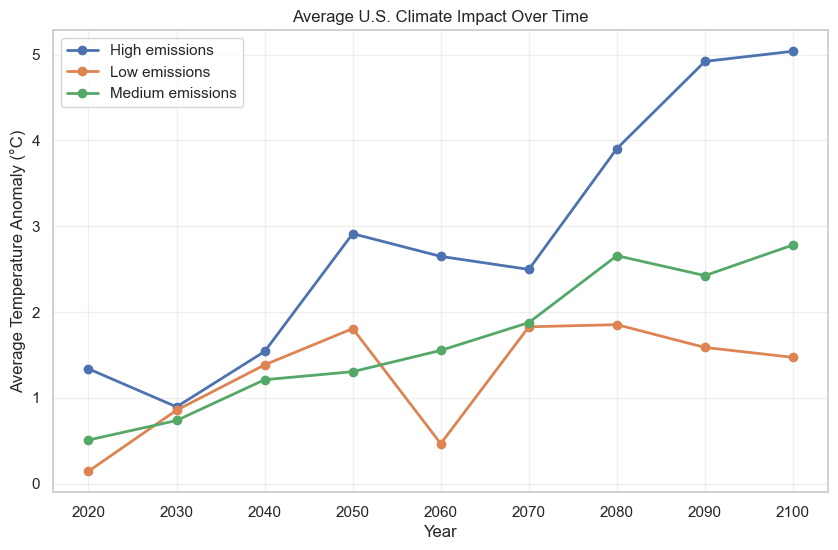

In [37]:
import matplotlib.pyplot as plt

scenario_trend = (
    state_df
    .groupby(["year", "scenario_label"])["temp_anomaly"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

for scenario in scenario_trend["scenario_label"].unique():
    subset = scenario_trend[
        scenario_trend["scenario_label"] == scenario
    ]

    plt.plot(
        subset["year"],
        subset["temp_anomaly"],
        marker="o",
        linewidth=2,
        label=scenario
    )

plt.xlabel("Year")
plt.ylabel("Average Temperature Anomaly (°C)")
plt.title("Average U.S. Climate Impact Over Time")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

overall warming increases over time across scenarios

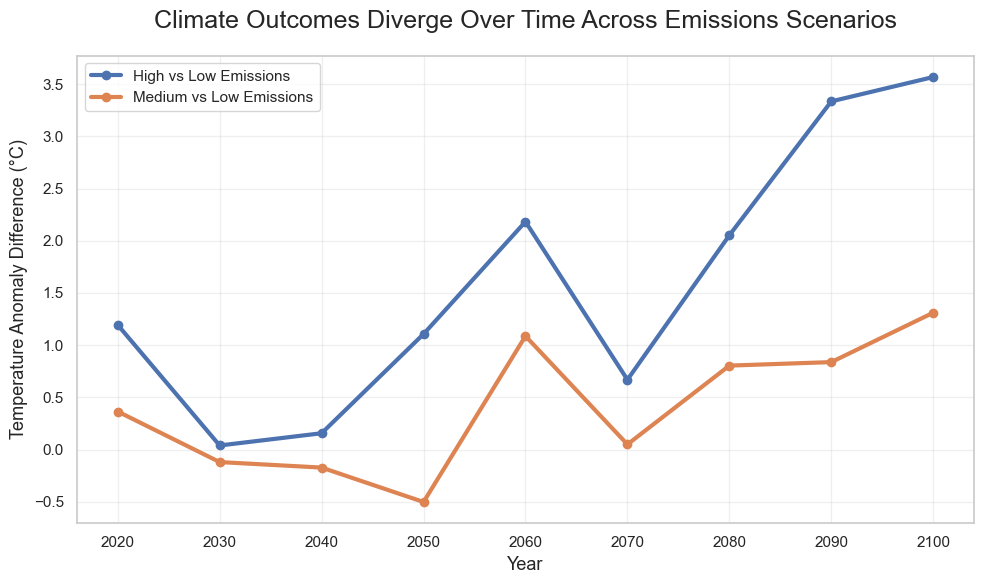

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Average anomaly by year + scenario
# ==========================================

avg_df = (
    state_df
    .groupby(["year", "scenario"])["temp_anomaly"]
    .mean()
    .reset_index()
)

# ==========================================
# Pivot
# ==========================================

pivot = avg_df.pivot(
    index="year",
    columns="scenario",
    values="temp_anomaly"
)

# ==========================================
# Scenario gaps
# ==========================================

pivot["ssp585_minus_ssp126"] = (
    pivot["ssp585"] - pivot["ssp126"]
)

pivot["ssp245_minus_ssp126"] = (
    pivot["ssp245"] - pivot["ssp126"]
)

# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    pivot.index,
    pivot["ssp585_minus_ssp126"],
    marker="o",
    linewidth=3,
    label="High vs Low Emissions"
)

plt.plot(
    pivot.index,
    pivot["ssp245_minus_ssp126"],
    marker="o",
    linewidth=3,
    label="Medium vs Low Emissions"
)

plt.title(
    "Climate Outcomes Diverge Over Time Across Emissions Scenarios",
    fontsize=18,
    pad=20
)

plt.xlabel("Year", fontsize=13)
plt.ylabel("Temperature Anomaly Difference (°C)", fontsize=13)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

emissions choices increasingly matter over time

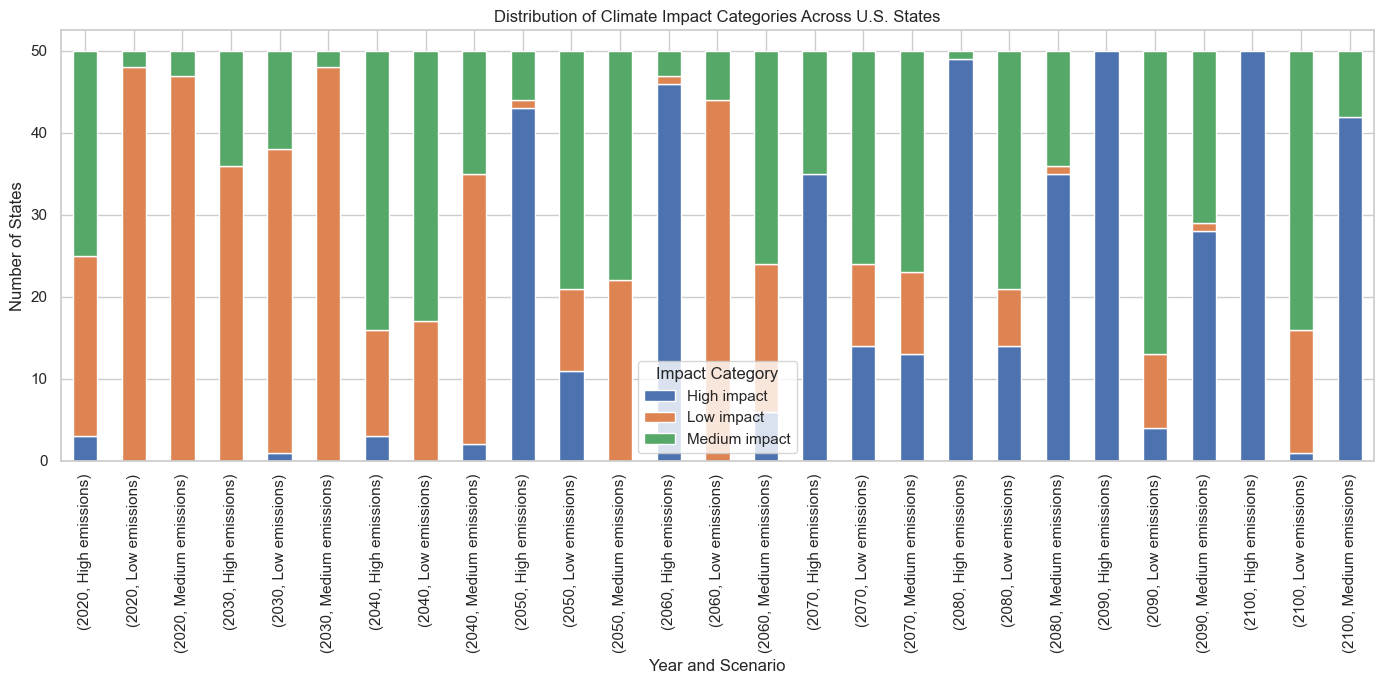

In [41]:
import matplotlib.pyplot as plt

pivot = (
    category_counts
    .pivot_table(
        index=["year", "scenario_label"],
        columns="impact_category",
        values="state_count",
        fill_value=0
    )
)

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.ylabel("Number of States")
plt.xlabel("Year and Scenario")
plt.title("Distribution of Climate Impact Categories Across U.S. States")

plt.legend(title="Impact Category")
plt.tight_layout()

plt.show()

states shift from low/medium into high-impact categories over time

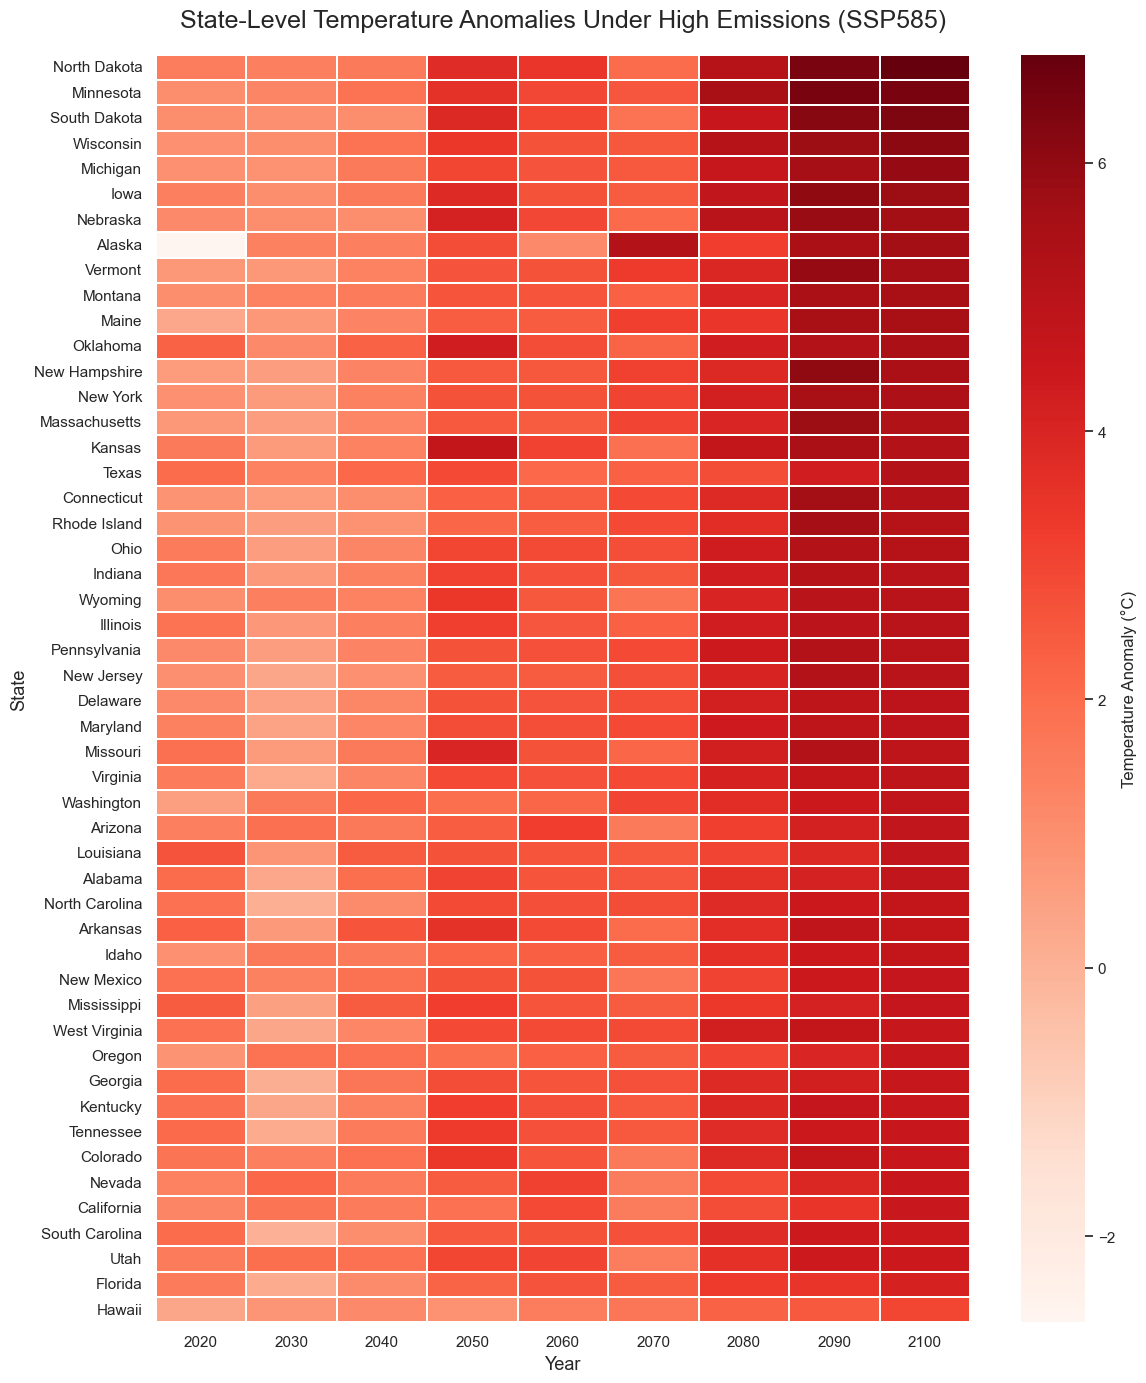

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# SSP585 only
# ==========================================

heat_df = state_df[state_df["scenario"] == "ssp585"].copy()

# ==========================================
# Pivot table
# rows = states
# cols = years
# values = temp anomaly
# ==========================================

heat_pivot = heat_df.pivot_table(
    index="state",
    columns="year",
    values="temp_anomaly"
)

# ==========================================
# Sort states by 2100 warming
# ==========================================

heat_pivot = heat_pivot.sort_values(
    by=2100,
    ascending=False
)

# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(12, 14))

sns.heatmap(
    heat_pivot,
    cmap="Reds",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={
        "label": "Temperature Anomaly (°C)"
    }
)

plt.title(
    "State-Level Temperature Anomalies Under High Emissions (SSP585)",
    fontsize=18,
    pad=20
)

plt.xlabel("Year", fontsize=13)
plt.ylabel("State", fontsize=13)

plt.tight_layout()
plt.show()

climate impacts vary spatially across states

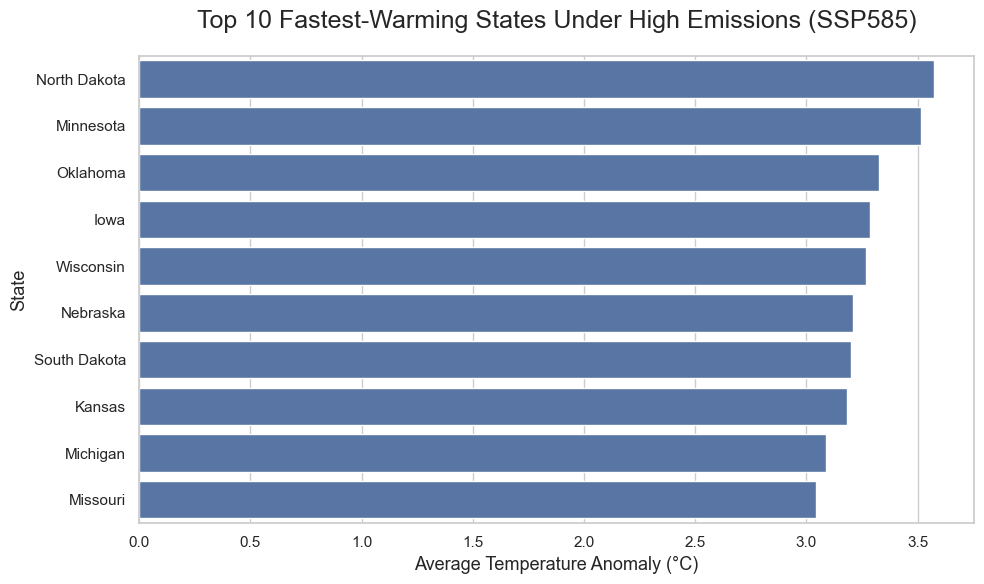

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# SSP585 only
# ==========================================

top_df = (
    state_df[state_df["scenario"] == "ssp585"]
    .groupby("state")["temp_anomaly"]
    .mean()
    .reset_index()
)

# ==========================================
# Top 10 highest average anomaly
# ==========================================

top_df = top_df.sort_values(
    "temp_anomaly",
    ascending=False
).head(10)

# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_df,
    x="temp_anomaly",
    y="state"
)

plt.title(
    "Top 10 Fastest-Warming States Under High Emissions (SSP585)",
    fontsize=18,
    pad=20
)

plt.xlabel("Average Temperature Anomaly (°C)", fontsize=13)
plt.ylabel("State", fontsize=13)

plt.tight_layout()
plt.show()

some states experience disproportionately large warming